In [30]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("solar_plant_generation_dataset.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)


# Extract time features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

#  DEFINE FEATURES AND TARGET

# Historical features (available for past days)
weather_cols = [
    'solar_irradiance_wm2',
    'ambient_temperature_c',
    'panel_temperature_c',
    'cloud_cover_percent'
]

# Add time features
time_cols = ['hour', 'day_of_week', 'month']

# Target
target_col = 'power_generation_kw'

# All features for the sequence
all_features = weather_cols + time_cols



# Scale features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit on all data (we'll use chronological split)
X_scaled = scaler_X.fit_transform(df[all_features])
y_scaled = scaler_y.fit_transform(df[[target_col]]).flatten()


#  CREATE SEQUENCES

SEQ_LENGTH = 24  # 1 day × 24 hours = 24 hourly steps

def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQ_LENGTH)

# TRAIN/TEST SPLIT (CHRONOLOGICAL)

split_idx = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# DATASET CLASS
class SolarDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y).unsqueeze(1)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SolarDataset(X_train, y_train)
test_dataset = SolarDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# LSTM MODEL
class SolarLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]  # Last timestep
        out = self.dropout(out)
        out = self.fc(out)
        return out

# Initialize
input_size = len(all_features)
model = SolarLSTM(input_size, hidden_size=32, num_layers=1, dropout=0.3)



In [ ]:
import torch
import torch.nn as nn

# TRAINING WITH BEST MODEL SAVING
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

EPOCHS = 50
train_losses = []
test_losses = []
best_test_loss = float('inf')

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            test_loss += criterion(outputs, y_batch).item()
    
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
    
    # Save best model
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), "best_solarLstm_model.pt")

print(f"\nBest Test Loss: {best_test_loss:.6f}")

Epoch 1/50 | Train Loss: 0.832825 | Test Loss: 0.329509
Epoch 2/50 | Train Loss: 0.177728 | Test Loss: 0.089871
Epoch 3/50 | Train Loss: 0.129403 | Test Loss: 0.097348
Epoch 4/50 | Train Loss: 0.115871 | Test Loss: 0.078380
Epoch 5/50 | Train Loss: 0.110906 | Test Loss: 0.079734
Epoch 6/50 | Train Loss: 0.106783 | Test Loss: 0.072467
Epoch 7/50 | Train Loss: 0.104707 | Test Loss: 0.069406
Epoch 8/50 | Train Loss: 0.099849 | Test Loss: 0.074834
Epoch 9/50 | Train Loss: 0.099986 | Test Loss: 0.078649
Epoch 10/50 | Train Loss: 0.098998 | Test Loss: 0.069301
Epoch 11/50 | Train Loss: 0.099897 | Test Loss: 0.068410
Epoch 12/50 | Train Loss: 0.097885 | Test Loss: 0.064932
Epoch 13/50 | Train Loss: 0.099139 | Test Loss: 0.063971
Epoch 14/50 | Train Loss: 0.091286 | Test Loss: 0.063553
Epoch 15/50 | Train Loss: 0.095892 | Test Loss: 0.062266
Epoch 16/50 | Train Loss: 0.094437 | Test Loss: 0.068278
Epoch 17/50 | Train Loss: 0.093686 | Test Loss: 0.075059
Epoch 18/50 | Train Loss: 0.099133 | Tes

In [42]:
import torch
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = SolarLSTM(
    input_size=len(all_features),
    hidden_size=32,
    num_layers=1,
    dropout=0.3
)

model.load_state_dict(torch.load("best_solarLstm_model.pt"))

#Evaluation
model.eval()
with torch.no_grad():
    y_pred_scaled = model(torch.FloatTensor(X_test)).numpy().flatten()

# Inverse transform to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Metrics
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print("EVALUATION RESULTS")
print(f"MAE:  {mae:.2f} kW")
print(f"RMSE: {rmse:.2f} kW")
print(f"R²:   {r2:.4f}")

EVALUATION RESULTS
MAE:  6.64 kW
RMSE: 11.94 kW
R²:   0.9351


In [43]:


# SAMPLE PREDICTIONS
print("SAMPLE PREDICTIONS (Last 10 Test Sequences)")

for i in range(-10, 0):
    actual = y_actual[i]
    predicted = y_pred[i]
    error = actual - predicted
    pct_error = abs(error / actual) * 100 if actual != 0 else 0
    
    print(f"Actual: {actual:7.2f} kW | Predicted: {predicted:7.2f} kW | Error: {error:+7.2f} kW ({pct_error:.1f}%)")

SAMPLE PREDICTIONS (Last 10 Test Sequences)
Actual:    0.00 kW | Predicted:    0.41 kW | Error:   -0.41 kW (0.0%)
Actual:    0.00 kW | Predicted:    0.81 kW | Error:   -0.81 kW (0.0%)
Actual:    0.00 kW | Predicted:    0.48 kW | Error:   -0.48 kW (0.0%)
Actual:    0.00 kW | Predicted:    0.56 kW | Error:   -0.56 kW (0.0%)
Actual:    0.00 kW | Predicted:    1.16 kW | Error:   -1.16 kW (0.0%)
Actual:    0.00 kW | Predicted:    0.25 kW | Error:   -0.25 kW (0.0%)
Actual:    0.00 kW | Predicted:   -1.02 kW | Error:   +1.02 kW (0.0%)
Actual:    0.00 kW | Predicted:   -1.29 kW | Error:   +1.29 kW (0.0%)
Actual:    0.00 kW | Predicted:    5.58 kW | Error:   -5.58 kW (0.0%)
Actual:   23.83 kW | Predicted:   23.53 kW | Error:   +0.30 kW (1.3%)


In [44]:
print(f"Model input size: {model.lstm.input_size}")
print(f"Number of features: {len(all_features)}")
print(f"Features: {all_features}")

Model input size: 7
Number of features: 7
Features: ['solar_irradiance_wm2', 'ambient_temperature_c', 'panel_temperature_c', 'cloud_cover_percent', 'hour', 'day_of_week', 'month']


Target day:  2025-07-27
Past day:    2025-07-26

Hours in target day: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Actual generation:   [  0.     0.     0.     0.     0.     0.     0.    25.04  34.02  76.87
  93.27  61.67  72.95 106.3  103.75  81.19  62.06  25.25   0.     0.
   0.     0.     0.     0.  ]

PREDICTION FOR 2025-07-27
Hour   Predicted      Actual         Error       
00           0.23 kW        0.00 kW     +0.23 kW
01           0.52 kW        0.00 kW     +0.52 kW
02           0.39 kW        0.00 kW     +0.39 kW
03          -0.61 kW        0.00 kW     -0.61 kW
04          -1.16 kW        0.00 kW     -1.16 kW
05           0.15 kW        0.00 kW     +0.15 kW
06           7.41 kW        0.00 kW     +7.41 kW
07          26.46 kW       25.04 kW     +1.42 kW
08          51.63 kW       34.02 kW    +17.61 kW
09          79.93 kW       76.87 kW     +3.06 kW
10         100.57 kW       93.27 kW     +7.30 kW
11         112.56 kW       61.67 kW    +50.89 kW


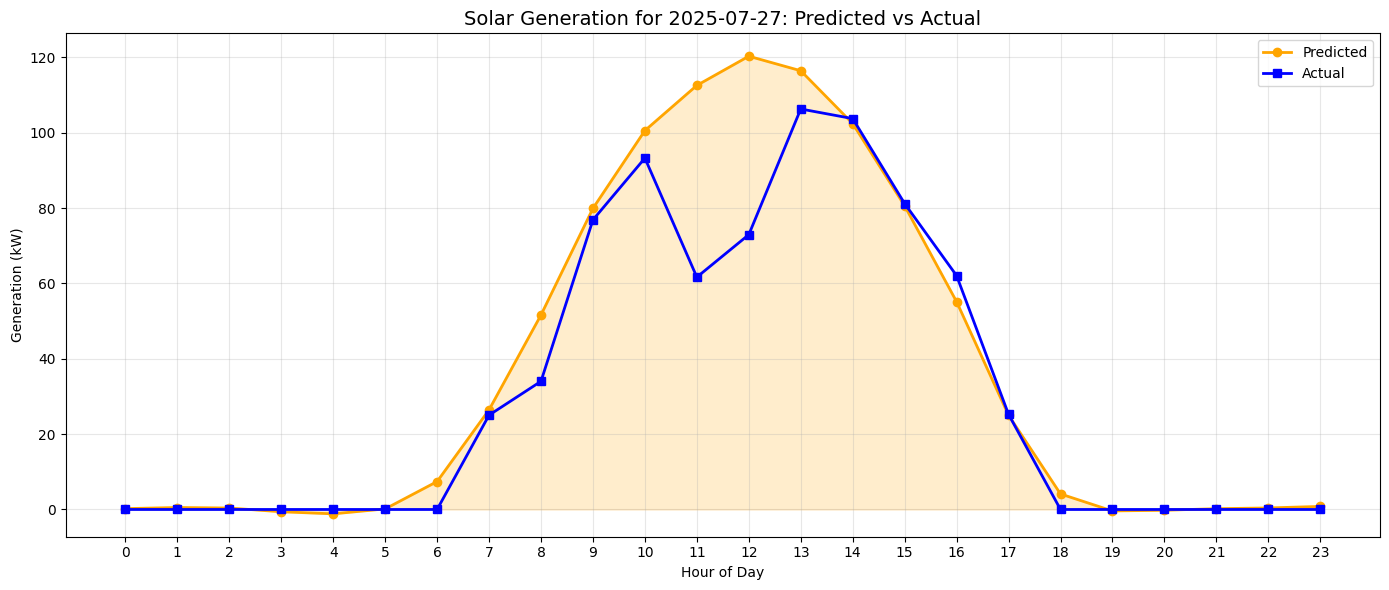

In [46]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1. FIND A COMPLETE CALENDAR DAY

df['date'] = df['timestamp'].dt.date
complete_days = df.groupby('date').size()
complete_days = complete_days[complete_days == 24].index.tolist()

target_date = complete_days[-1]
past_date = complete_days[-2]

print(f"Target day:  {target_date}")
print(f"Past day:    {past_date}")

# 2. PREPARE DATA

target_day_df = df[df['date'] == target_date].sort_values('timestamp').reset_index(drop=True)
past_day_df = df[df['date'] == past_date].sort_values('timestamp').reset_index(drop=True)

past_24h = past_day_df[all_features].values
tomorrow_24h = target_day_df[all_features].values
actual_tomorrow = target_day_df[target_col].values

print(f"\nHours in target day: {target_day_df['hour'].values}")
print(f"Actual generation:   {actual_tomorrow}")

# 3. PREDICT
def predict_tomorrow(model, scaler_X, scaler_y, past_24h, tomorrow_24h, feature_names):
    model.eval()
    predictions = []
    current_seq = past_24h.copy()
    
    for hour in range(24):
        # Convert to DataFrame to match scaler's fitted feature names
        current_seq_df = pd.DataFrame(current_seq, columns=feature_names)
        X_scaled = scaler_X.transform(current_seq_df)
        X_tensor = torch.FloatTensor(X_scaled).unsqueeze(0)
        
        with torch.no_grad():
            y_pred_scaled = model(X_tensor).numpy()
        
        next_gen = scaler_y.inverse_transform(y_pred_scaled).flatten()[0]
        predictions.append(next_gen)
        
        current_seq = np.vstack([current_seq[1:], tomorrow_24h[hour]])
    
    return np.array(predictions)

predictions = predict_tomorrow(model, scaler_X, scaler_y, past_24h, tomorrow_24h, all_features)

# 4. COMPARE

print(f"\nPREDICTION FOR {target_date}")
print(f"{'Hour':<6} {'Predicted':<14} {'Actual':<14} {'Error':<12}")

for h in range(24):
    pred = predictions[h]
    actual = actual_tomorrow[h]
    error = pred - actual
    print(f"{h:02d}     {pred:>10.2f} kW  {actual:>10.2f} kW  {error:>+8.2f} kW")

print(f"Total  {predictions.sum():>10.2f} kWh {actual_tomorrow.sum():>10.2f} kWh {predictions.sum() - actual_tomorrow.sum():>+8.2f}")

# 5. VISUALIZE

plt.figure(figsize=(14, 6))
plt.plot(range(24), predictions, marker='o', label='Predicted', linewidth=2, color='orange')
plt.plot(range(24), actual_tomorrow, marker='s', label='Actual', linewidth=2, color='blue')
plt.fill_between(range(24), 0, predictions, alpha=0.2, color='orange')
plt.title(f"Solar Generation for {target_date}: Predicted vs Actual", fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Generation (kW)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()